In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, cohen_kappa_score)
import json

# EEGNet definition (must redefine to load the model)
class EEGNet(nn.Module):
    def __init__(self, num_classes=4, channels=22, timepoints=1001,
                 F1=8, D=2, F2=16, dropout=0.5):
        super(EEGNet, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1*D, kernel_size=(channels, 1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, kernel_size=(1, 16),
                      padding=(0, 8), groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )
        self._to_linear = self._get_flatten_size(channels, timepoints)
        self.classifier = nn.Linear(self._to_linear, num_classes)

    def _get_flatten_size(self, channels, timepoints):
        x = torch.zeros(1, 1, channels, timepoints)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# load data
data = np.load('../data/preprocessed.npz')
X_test  = torch.FloatTensor(data['X_test']).unsqueeze(1)
y_test  = data['y_test']

# load model
device = torch.device('cpu')
model = EEGNet(num_classes=4, channels=22, timepoints=1001)
model.load_state_dict(torch.load('../data/eegnet_model.pth',
                                  map_location=device))
model.eval()

print("Model and data loaded successfully")

Model and data loaded successfully


In [2]:
# get predictions
with torch.no_grad():
    outputs = model(X_test)
    probabilities = torch.softmax(outputs, dim=1).numpy()
    _, predicted = torch.max(outputs, 1)
    y_pred = predicted.numpy()

# core metrics
accuracy = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print("=" * 45)
print("  EEGNet — Final Evaluation Results")
print("=" * 45)
print(f"  Dataset:     BCI Competition IV — 2a")
print(f"  Subject:     A01")
print(f"  Test trials: {len(y_test)}")
print(f"  Classes:     4 motor imagery types")
print("-" * 45)
print(f"  Accuracy:    {accuracy*100:.1f}%")
print(f"  Kappa score: {kappa:.3f}")
print(f"  Baseline:    25.0% (random chance)")
print(f"  Benchmark:   ~72.0% (published EEGNet)")
print("=" * 45)

class_names = ['Left hand', 'Right hand', 'Feet', 'Tongue']
print(f"\nPer-class results:")
print(classification_report(y_test, y_pred, target_names=class_names))

  EEGNet — Final Evaluation Results
  Dataset:     BCI Competition IV — 2a
  Subject:     A01
  Test trials: 58
  Classes:     4 motor imagery types
---------------------------------------------
  Accuracy:    63.8%
  Kappa score: 0.519
  Baseline:    25.0% (random chance)
  Benchmark:   ~72.0% (published EEGNet)

Per-class results:
              precision    recall  f1-score   support

   Left hand       0.55      0.40      0.46        15
  Right hand       0.60      0.86      0.71        14
        Feet       0.70      0.47      0.56        15
      Tongue       0.71      0.86      0.77        14

    accuracy                           0.64        58
   macro avg       0.64      0.65      0.63        58
weighted avg       0.64      0.64      0.62        58



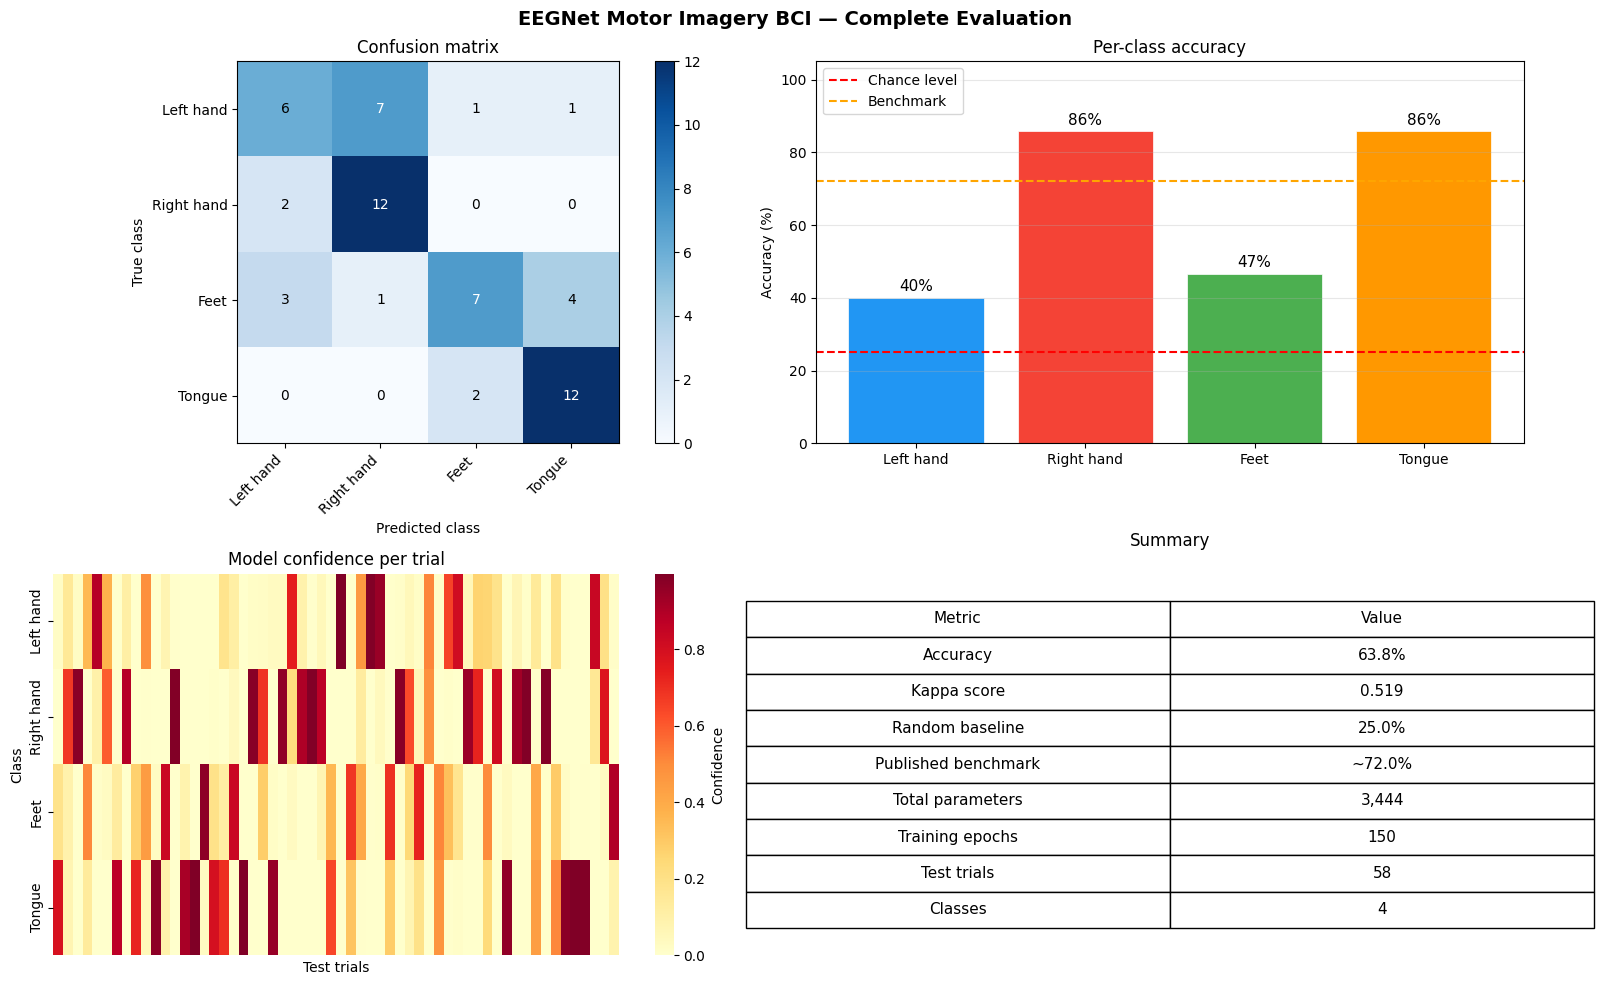

In [3]:
fig = plt.figure(figsize=(16, 10))

# confusion matrix
ax1 = fig.add_subplot(2, 2, 1)
cm = confusion_matrix(y_test, y_pred)
im = ax1.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax1)
ax1.set_xticks(range(4))
ax1.set_yticks(range(4))
ax1.set_xticklabels(class_names, rotation=45, ha='right')
ax1.set_yticklabels(class_names)
thresh = cm.max() / 2
for i in range(4):
    for j in range(4):
        ax1.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
ax1.set_title('Confusion matrix')
ax1.set_ylabel('True class')
ax1.set_xlabel('Predicted class')

# per class accuracy bar chart
ax2 = fig.add_subplot(2, 2, 2)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
bars = ax2.bar(class_names, per_class_acc * 100, color=colors, 
               edgecolor='white', linewidth=0.5)
ax2.axhline(y=25, color='red', linestyle='--', 
            label='Chance level', linewidth=1.5)
ax2.axhline(y=72, color='orange', linestyle='--',
            label='Benchmark', linewidth=1.5)
for bar, acc in zip(bars, per_class_acc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc*100:.0f}%', ha='center', va='bottom', fontsize=11)
ax2.set_ylim(0, 105)
ax2.set_title('Per-class accuracy')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# prediction confidence heatmap
ax3 = fig.add_subplot(2, 2, 3)
sns.heatmap(probabilities.T, ax=ax3, cmap='YlOrRd',
            yticklabels=class_names, xticklabels=False,
            cbar_kws={'label': 'Confidence'})
ax3.set_title('Model confidence per trial')
ax3.set_xlabel('Test trials')
ax3.set_ylabel('Class')

# summary metrics
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')
summary = [
    ['Metric', 'Value'],
    ['Accuracy', f'{accuracy*100:.1f}%'],
    ['Kappa score', f'{kappa:.3f}'],
    ['Random baseline', '25.0%'],
    ['Published benchmark', '~72.0%'],
    ['Total parameters', '3,444'],
    ['Training epochs', '150'],
    ['Test trials', '58'],
    ['Classes', '4'],
]
table = ax4.table(cellText=summary[1:], colLabels=summary[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)
ax4.set_title('Summary', pad=20)

plt.suptitle('EEGNet Motor Imagery BCI — Complete Evaluation', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()